# Lesson 02 — CART Regression Loss and Split Selection

## Objective: replace a guessed threshold with a data-driven choice

In Lesson 01, we manually chose `MedInc = 4.0` to split observations into two leaves. This lesson replaces that human guess with the core CART split-selection procedure: generate every meaningful candidate threshold, evaluate the predictions produced by each split, and choose the threshold with the smallest total squared error.

The midpoint thresholds are only the finite set of split proposals that CART needs to test. For each proposal, we will:

1. divide the rows into left (`x ≤ threshold`) and right (`x > threshold`) children;
2. use each child's mean target as its leaf prediction;
3. calculate the squared-error loss in each child;
4. add the child losses to obtain the total split loss; and
5. select the threshold with the lowest total loss.

By the end of the lesson, you should be able to calculate and implement the best split for one feature at one node. We will not yet recurse, grow a complete tree, or consider multiple features.

## Reuse the deterministic California Housing slice

We reuse the same 12 real rows from Lesson 01 so that the new split calculation stays connected to familiar data. The rows are sorted by `MedInc`, making every possible boundary visible between neighboring feature values.

For row $i$:

- $x_i$ is its `MedInc` feature value, measured in units of $10,000; and
- $y_i$ is its observed `MedHouseVal` target, measured in units of $100,000.

The arrays `x` and `y` preserve this displayed order.

In [1]:
import numpy as np
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
housing_rows = housing.frame.loc[:, ["MedInc", "MedHouseVal"]]

sorted_rows = (
    housing_rows.reset_index(names="source_row")
    .sort_values(by=["MedInc", "source_row"])
    .reset_index(drop=True)
)

rank_positions = np.linspace(
    0,
    len(sorted_rows) - 1,
    num=12,
    dtype=int,
)

housing_slice = sorted_rows.iloc[rank_positions].reset_index(drop=True)

x = housing_slice["MedInc"].to_numpy()
y = housing_slice["MedHouseVal"].to_numpy()

housing_slice

,source_row,MedInc,MedHouseVal
0,73,0.4999,0.675
1,241,1.8472,1.370
2,3789,2.2756,2.214
3,19601,2.6406,1.297
4,5841,3.0179,2.725
5,5606,3.3427,1.542
6,19373,3.7031,1.733
7,6743,4.1136,2.799
8,16665,4.6071,2.399
9,8554,5.2500,2.472


## Turn one promising gap into a candidate split

By eye, the gap between rows 9 and 10 looks promising because it separates the targets `4.500` and `4.000` from the mostly lower targets before them. We represent that gap with its midpoint threshold:

$$
t = \frac{x_9 + x_{10}}{2} = 5.7723.
$$

Rows with $x_i \le t$ enter the left child; rows with $x_i > t$ enter the right child. Each child predicts the mean of the targets assigned to it:

$$
\hat{y}_L = \operatorname{mean}(y_i : x_i \le t), \qquad \hat{y}_R = \operatorname{mean}(y_i : x_i > t).
$$

These map to `threshold`, `left_mask`, `right_mask`, `left_prediction`, and `right_prediction` in the code below.

In [2]:
threshold = (x[9] + x[10]) / 2

left_mask = x <= threshold
right_mask = x > threshold

left_prediction = y[left_mask].mean()
right_prediction = y[right_mask].mean()

threshold, left_prediction, right_prediction

(np.float64(5.7722999999999995),
 np.float64(1.9226000000000003),
 np.float64(4.25))

### Check the partition

This candidate should send 10 rows left and 2 rows right. The assertions also verify the essential partition rule: every row reaches one child, and no row reaches both children. Passing assertions produce no output.

In [3]:
assert left_mask.sum() == 10
assert right_mask.sum() == 2
assert not (left_mask & right_mask).any()
assert (left_mask | right_mask).all()

## Measure how well this candidate predicts

A **residual** is the difference between an observed target and the prediction it receives. For example, a left-row residual is $y_i - \hat{y}_L$. Squaring prevents negative and positive misses from cancelling.

**RSS stands for Residual Sum of Squares.** A residual is one target-minus-prediction difference; RSS squares those residuals and adds them. In the sums below, $i : x_i \le t$ means ‘each row index $i$ whose feature value $x_i$ is at most the threshold $t$.’ Similarly, $i : x_i > t$ means the rows assigned to the right child. The left and right leaf losses are:

$$
\operatorname{RSS}_L = \sum_{i : x_i \le t}(y_i - \hat{y}_L)^2, \qquad \operatorname{RSS}_R = \sum_{i : x_i > t}(y_i - \hat{y}_R)^2.
$$

The candidate needs one overall score, so we add the child losses:

$$
L_{\mathrm{split}}(t) = \operatorname{RSS}_L + \operatorname{RSS}_R.
$$

In code, these quantities are `left_residuals`, `right_residuals`, `left_loss`, `right_loss`, and `split_loss`. A lower `split_loss` means the two leaf predictions fit their assigned targets more closely.

In [4]:
left_residuals = y[left_mask] - left_prediction
right_residuals = y[right_mask] - right_prediction

# Sum the squared left residuals.
left_loss = (left_residuals**2).sum()

# Sum the squared right residuals.
right_loss = (right_residuals**2).sum()

# Combine both child losses into one candidate score.
split_loss = left_loss + right_loss

left_loss, right_loss, split_loss

(np.float64(4.459686400000001),
 np.float64(0.125),
 np.float64(4.584686400000001))

### Check the candidate score

For this visible split, the left RSS is approximately `4.4597`, the right RSS is `0.125`, and their sum is approximately `4.5847`. `np.isclose` checks these decimal results with a small floating-point tolerance instead of requiring exact binary equality. This score evaluates only the candidate $t = 5.7723$; we have not yet proved that it is the best candidate.

In [5]:
assert np.isclose(left_loss, 4.4596864)
assert np.isclose(right_loss, 0.125)
assert np.isclose(split_loss, left_loss + right_loss)

## Generate every distinct candidate threshold

The candidate $t = 5.7723$ was chosen by eye, but CART must test every grouping that the sorted feature values permit. `np.unique(x)` first removes duplicate feature values because equal values cannot be separated by a threshold.

`left_neighbors` and `right_neighbors` contain the same distinct values shifted by one position. Each aligned pair is one adjacent gap, and its midpoint is the candidate representing that gap. With 12 distinct values, we expect 11 candidates.

In [6]:
# Equal feature values cannot be separated, so keep each value only once.
unique_x = np.unique(x)
print(unique_x)

# Align every distinct value with the distinct value immediately after it.
left_neighbors = unique_x[:-1]
right_neighbors = unique_x[1:]
print(left_neighbors)
print(right_neighbors)

# Represent each adjacent gap with one reproducible midpoint candidate.
thresholds = (left_neighbors + right_neighbors) / 2
thresholds

[ 0.4999  1.8472  2.2756  2.6406  3.0179  3.3427  3.7031  4.1136  4.6071
  5.25    6.2946 15.0001]
[0.4999 1.8472 2.2756 2.6406 3.0179 3.3427 3.7031 4.1136 4.6071 5.25
 6.2946]
[ 1.8472  2.2756  2.6406  3.0179  3.3427  3.7031  4.1136  4.6071  5.25
  6.2946 15.0001]


array([ 1.17355,  2.0614 ,  2.4581 ,  2.82925,  3.1803 ,  3.5229 ,
        3.90835,  4.36035,  4.92855,  5.7723 , 10.64735])

### Check the candidate gaps

The first assertion checks the candidate count. The next two verify that every midpoint lies strictly between its left and right neighboring feature values, so every candidate creates two non-empty children. The final checks anchor the calculation to the visible first and last gaps.

In [7]:
assert thresholds.size == unique_x.size - 1
assert np.all(unique_x[:-1] < thresholds)
assert np.all(thresholds < unique_x[1:])

assert np.isclose(thresholds[0], 1.17355)
assert np.isclose(thresholds[-1], 10.64735)

## Evaluate every candidate with the same rule

The loop below generalizes the one-candidate calculation. For each threshold it forms the two children, computes their mean predictions, calculates left and right RSS, and records their sum as `total_loss`.

Each dictionary becomes one row of `candidate_table`. This makes the comparison transparent: the counts show the partition, the predictions show what each leaf returns, and the three loss columns show how the candidate is scored.

In [8]:
import pandas as pd

# Accumulate one transparent result record for every candidate threshold.
candidate_rows = []
for candidate in thresholds:
    # Partition all targets using this candidate's left/right rule.
    candidate_left_mask = x <= candidate
    candidate_right_mask = x > candidate

    left_targets = y[candidate_left_mask]
    right_targets = y[candidate_right_mask]

    # Each leaf's shared prediction is its own target mean.
    candidate_left_prediction = left_targets.mean()
    candidate_right_prediction = right_targets.mean()

    # Measure each prediction miss before squaring and summing the misses.
    candidate_left_residuals = left_targets - candidate_left_prediction
    candidate_right_residuals = right_targets - candidate_right_prediction

    candidate_left_loss = (candidate_left_residuals**2).sum()
    candidate_right_loss = (candidate_right_residuals**2).sum()

    # Store the partition, predictions, child losses, and combined score.
    candidate_rows.append(
        {
            "threshold": candidate,
            "left_count": left_targets.size,
            "right_count": right_targets.size,
            "left_prediction": candidate_left_prediction,
            "right_prediction": candidate_right_prediction,
            "left_loss": candidate_left_loss,
            "right_loss": candidate_right_loss,
            "total_loss": candidate_left_loss + candidate_right_loss,
        }
    )

candidate_table = pd.DataFrame(candidate_rows)
candidate_table

,threshold,left_count,right_count,left_prediction,right_prediction,left_loss,right_loss,total_loss
0,1.17355,1,11,0.675000,2.459182,0.000000,10.694642,10.694642
1,2.06140,2,10,1.022500,2.568100,0.241513,9.389693,9.631205
2,2.45810,3,9,1.419667,2.607444,1.187961,9.250374,10.438335
3,2.82925,4,8,1.389000,2.771250,1.199246,7.318451,8.517697
4,3.18030,5,7,1.656200,2.777857,2.627163,7.316007,9.943170
5,3.52290,6,6,1.637167,2.983833,2.638031,5.534107,8.172138
6,3.90835,7,5,1.650857,3.234000,2.645903,3.656606,6.302509
7,4.36035,8,4,1.794375,3.342750,3.799356,3.420075,7.219431
8,4.92855,9,3,1.861556,3.657333,4.124308,2.232523,6.356831
9,5.77230,10,2,1.922600,4.250000,4.459686,0.125000,4.584686


### Check the candidate table

There must be exactly one table row per candidate threshold. The child-count checks make the no-empty-child requirement explicit for every candidate, not only for the original worked split.

In [9]:
assert len(candidate_table) == thresholds.size
assert (candidate_table["left_count"] > 0).all()
assert (candidate_table["right_count"] > 0).all()

## Select the minimum-loss candidate

`argmin` returns the position of the smallest value rather than the value itself. Here it finds the position of the smallest `total_loss`. `candidate_table.iloc[best_position]` then retrieves the complete table row at that integer position.

The result is the selected split: threshold `5.7723`, left prediction `1.9226`, right prediction `4.25`, and total RSS `4.584686`.

In [10]:
# Extract the comparable score from every candidate-table row.
total_losses = candidate_table["total_loss"].to_numpy()

# argmin returns the integer position where total loss is smallest.
best_position = total_losses.argmin()

# iloc uses that integer position to retrieve the complete winning row.
best_candidate = candidate_table.iloc[best_position]

best_candidate

threshold            5.772300
left_count          10.000000
right_count          2.000000
left_prediction      1.922600
right_prediction     4.250000
left_loss            4.459686
right_loss           0.125000
total_loss           4.584686
Name: 9, dtype: float64

### Check the selected split

The selected row's loss must equal the minimum loss displayed anywhere in the table. The threshold check also confirms that the automated result matches the promising gap identified earlier by eye.

In [11]:
assert np.isclose(best_candidate["total_loss"], candidate_table["total_loss"].min())
assert np.isclose(best_candidate["threshold"], 5.7723)

## Visualize the threshold comparison

The table contains the complete numerical comparison; this plot gives the same information a geometric shape. Each point is one candidate threshold and its total left-plus-right RSS. The highlighted point must coincide with the curve's minimum, visually connecting `argmin` to the chosen split.

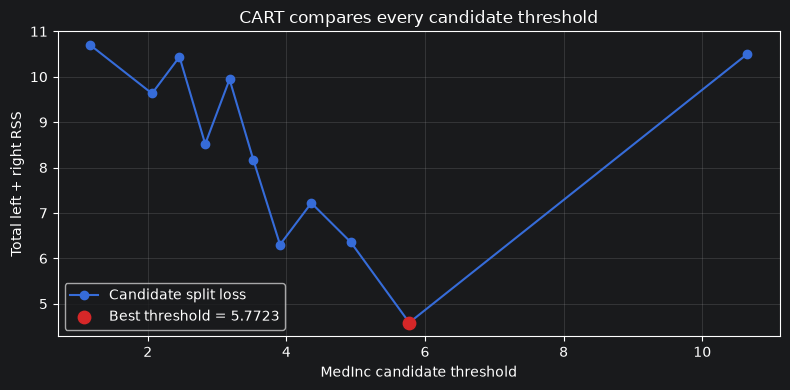

In [12]:
import matplotlib.pyplot as plt

# Convert the selected pandas values into scalars used by Matplotlib.
best_threshold = float(best_candidate["threshold"])
best_loss = float(best_candidate["total_loss"])

fig, ax = plt.subplots(figsize=(8, 4))

# Connect all candidate scores to show how loss changes with threshold.
ax.plot(
    candidate_table["threshold"],
    candidate_table["total_loss"],
    marker="o",
    label="Candidate split loss",
)

# Highlight the same minimum row selected numerically by argmin.
ax.scatter(
    best_threshold,
    best_loss,
    color="tab:red",
    s=80,
    zorder=3,
    label=f"Best threshold = {best_threshold:.4f}",
)

ax.set(
    xlabel="MedInc candidate threshold",
    ylabel="Total left + right RSS",
    title="CART compares every candidate threshold",
)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

In [13]:
parent_prediction = y.mean()
parent_residuals = y - parent_prediction
parent_loss = (parent_residuals**2).sum()

loss_reduction = parent_loss - best_loss

parent_prediction, parent_loss, best_loss, loss_reduction

(np.float64(2.3105),
 np.float64(13.612670999999999),
 4.584686400000001,
 np.float64(9.027984599999998))

In [14]:
assert np.isclose(parent_loss, 13.612671)
assert np.isclose(loss_reduction, 9.0279846)
assert loss_reduction > 0

In [15]:
from boosted_trees_course.tree import best_split_1d

result = best_split_1d(x, y)

assert np.isclose(result.threshold, 5.7723)
assert np.isclose(result.left_prediction, 1.9226)
assert np.isclose(result.right_prediction, 4.25)
assert np.isclose(result.total_loss, 4.5846864)